**Conceptos clave del proyecto**: Antes de empezar con el proyecto, es necesario entender ciertos conceptos claves:

*   Modelos matemáticos: Se define como modelo matemático, al conjunto de **variables**, **parámetros** y **relaciones matemáticas** que permiten representar fenómemos del mundo real de una forma. Para así estudiar las características de nuestro fenómeno de estudio. Cada uno de estos términos realiza distintas funciones dentro de un modelo:

$\hspace{2cm}$- Variables: Cantidad variable dentro de un sistema (ej: tiempo, cantidad de individuos). Así mismo, podemos clasificar las variables en dos tipos:

$\hspace{0.5cm}$ Discretas: Datos enteros y contables (lista de un curso, cantidad de personas
de una vivienda, etc).

$\hspace{0.5cm}$Continuas: Datos contenidos dentro de intervalos (como el peso o la altura).

$\hspace{2cm}$- Parámetros: Valores constantes, le atribuyen características al sistema en el cual se hallan (ej: capacidad de carga, tasa de crecimiento).\

$\hspace{2cm}$- Relaciones matemáticas: Procesos lógicos que nos permiten relacionar distintos tipos de variables entre si, usualmente expresados mediante ecuaciones.

$\hspace{0.5cm}$-Para este proyecto, nos centramos en los **modelos poblacionales** y sus características.

* Modelo poblacional: Aquel modelo matemático que permite el estudio de
seres vivos presentes que viven en poblaciones, permiten estudiar el crecimiento y comportamiento de una población a través del tiempo. Así como la natalidad y mortalidad de una población ante fenómenos adversos.
<br>\
**Modelos usados para este proyecto:**

*   Modelo de Malthus: Describe el crecimiento de una poblacion cualquiera de forma **exponencial**. A través de una progresión geométrica.\
Su forma discreta se representa mediante la fórmula:
$$X_{n+1} = r⋅X_n $$
Donde:
- Tasa de crecimiento de la población (r) = $1+b-d$
<br>

*   Modelo Logístico: Plantea el concepto de **capacidad de carga**, siendo este el límite de individuos de una población que el ecosistema puede sostener. Esto límita el crecimiento poblacional, haciendo que su crecimiento sea sigmoide. Representado con la siguiente fórmula:
$$X_{n+1} = X_{n} + 𝜌X_{n}(L-X_{n})$$
Donde:
- L = Capacidad de carga del sistema
- 𝜌 = Tasa de crecimiento del sistema (depende de L).
<br>
Importante: Ambos modelos trabajan con variable discreta.
<br>

**Método de Euler para el uso de modelos continuos:**


*   El método de Euler es una herramienta que nos permite aproximar nuestros modelos con variables discretas a un modelo equivalente de **variable continua**. Para ello, usamos **ecuaciones diferenciales** que nos permitan entender como se comportan las poblaciones en pequeños intervalos de tiempo.\
 Aplicándolo a ambos modelos poblacionales, obtenemos los siguientes resultados:\
 -**Malthus continuo**: $\frac{dX}{dt} = 𝜶X$\
 -**Logístico continuo**: $\frac{dX}{dt} = kX(1-\frac{X}{t})$\
  Donde: 𝜶 y 𝑲 son las respectivas tasas de crecimiento instantáneo de cada modelo.
  <br>

  Para evaluar el comportamiento de ambos modelos, decidimos crear los siguientes códigos con el uso de IA, mientras que nuestro grupo se encargó de interpretar los resultados obtenidos, y así ver las diferencias entre las variantes discreta y continua de cada modelo.

---
\
$\hspace{0.5cm}$ En primer lugar, se definen los parámetros y variables con los cuales vamos a trabajar y que librerias usamos para que funcione nuestro código:


In [1]:
# Dinámica de poblaciones
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parámetros Generales ---
X0 = 10        # Población inicial
t_max = 50     # Tiempo máximo
dt = 0.1       # Paso de tiempo para Euler/Continuo
t_eval = np.arange(0, t_max + dt, dt)

# --- Parámetros Malthus ---
r_disc = 1.05  # Tasa discreta (Xn+1 = r * Xn)
alpha = 0.05   # Tasa continua (dX/dt = alpha * X)

# --- Parámetros Logístico ---
L = 100        # Capacidad de carga
rho = 0.001    # Tasa intrínseca (discreto: rho, continuo: k)
k = rho * L    # Relación aproximada para comparación


$\hspace{0.5cm}$ En este caso, definimos algunos parámetros generales que se usan en ambos modelos, así como parámetros respectivos para Malthus y Euler. Definimos los siguientes parámetros:
- Población inicial ($X_0$)
- Tiempo máximo del gráfico ($t_{max}$)
- Intervalo de tiempo para Euler y modelo continuo ($dt$)
- Tasa de crecimiento para Malthus discreto y continuo ($r$, $𝝰$).
- Capacidad de carga para Logístico ($L$)
- Tasa de crecimiento para logístico discreto y continuo ($𝜌$, $k$)

# --- Implementación de modelos ---
$\hspace{0.5cm}$ A continuación, se definen las funciones discreta y continua para modelo de Malthus y logístico:

In [2]:
# Modelo de Malthus Discreto y Continuo:
def malthus_discreto(X0, r, steps):
    pob = [X0]
    for n in range(steps):
        pob.append(r * pob[-1])
    return np.array(pob)

def malthus_continuo(X0, alpha, t):
    return X0 * np.exp(alpha * t)

In [3]:
# Logístico Discreto y Continuo:
def logistico_discreto(X0, rho, L, steps):
    pob = [X0]
    for n in range(steps):
        xn = pob[-1]
        pob.append(xn + rho * xn * (L - xn))
    return np.array(pob)

def logistico_continuo_exacto(X0, k, L, t):
    return L / (1 + ((L - X0) / X0) * np.exp(-k * t))

In [4]:
# Método de Euler para EDO Logística:
# dX/dt = f(t, X) = k * X * (1 - X/L)
def euler_logistico(X0, k, L, t_vector):
    pob = np.zeros(len(t_vector))
    pob[0] = X0
    h = t_vector[1] - t_vector[0]
    for i in range(len(t_vector) - 1):
        f_val = k * pob[i] * (1 - pob[i] / L)
        pob[i+1] = pob[i] + h * f_val
    return pob

# Generación de Gráficos:
$\hspace{0.5cm}$ Por último, generamos los gráficos que nos permitan comprender el comportamiento de ambos modelos, así como comparar el trabajo con variable continua y discreta:

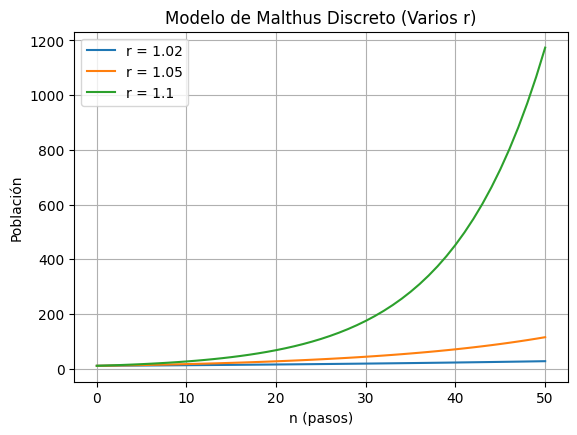

In [5]:
plt.figure(figsize=(14, 10))

# Gráfica 1: Curvas de Malthus para distintos r
plt.subplot(2, 2, 1)
for r in [1.02, 1.05, 1.10]:
    plt.plot(malthus_discreto(X0, r, t_max), label=f'r = {r}')
plt.title("Modelo de Malthus Discreto (Varios r)")
plt.xlabel("n (pasos)")
plt.ylabel("Población")
plt.legend()
plt.grid(True)

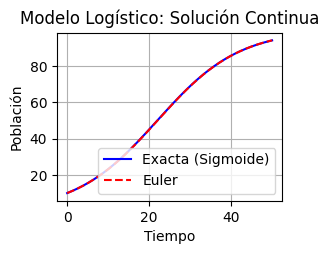

In [6]:
# Gráfica 2: Sigmoide Logística (Continua vs Euler)
plt.subplot(2, 2, 2)
sol_exacta = logistico_continuo_exacto(X0, k, L, t_eval)
sol_euler = euler_logistico(X0, k, L, t_eval)
plt.plot(t_eval, sol_exacta, 'b-', label='Exacta (Sigmoide)')
plt.plot(t_eval, sol_euler, 'r--', label='Euler')
plt.title("Modelo Logístico: Solución Continua")
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.grid(True)

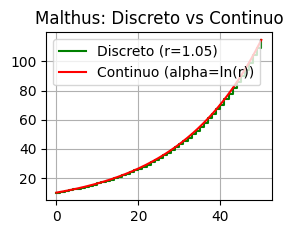

In [7]:
# Gráfica 3: Comparación Discreto vs Continuo (Malthus)
plt.subplot(2, 2, 3)
n_steps = np.arange(t_max + 1)
plt.step(n_steps, malthus_discreto(X0, r_disc, t_max), where='post', label='Discreto (r=1.05)', color='green')
plt.plot(t_eval, malthus_continuo(X0, np.log(r_disc), t_eval), 'r', label='Continuo (alpha=ln(r))')
plt.title("Malthus: Discreto vs Continuo")
plt.legend()
plt.grid(True)

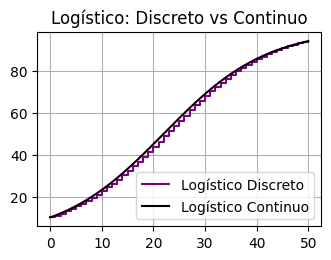

In [8]:
# Gráfica 4: Comparación Discreto vs Continuo (Logístico)
plt.subplot(2, 2, 4)
plt.step(n_steps, logistico_discreto(X0, rho, L, t_max), where='post', label='Logístico Discreto', color='purple')
plt.plot(t_eval, logistico_continuo_exacto(X0, k, L, t_eval), 'black', label='Logístico Continuo')
plt.title("Logístico: Discreto vs Continuo")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Interpretación de los gráficos:
$\hspace{0.5cm}$ En general, podemos notar que los modelos de variable continua presentan una curva más suave, dado que la tasa de crecimiento evalua a cada instante el comportamiento de la población, a diferencia de los modelos discretos, cuya tasa de crecimiento usa intervalos de tiempo más extensos\
$\hspace{0.5cm}$ Además, los modelos discretos y continuos de Malthus y logístico poseen un comportamiento similar, lo cual nos permite afirmar que la aproximación realizada usando el método de Euler es correcta en ambos casos.\
$\hspace{0.5cm}$ Es importante mencionar que, variar los parámetros de cada modelo puede ser interesante para conocer su utilidad en distintos contextos, así como conocer si el método de Euler es igual de útil como una aproximación continua en otros contextos.